In [21]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [22]:
# Load your dataset
df = pd.read_csv('./individual_stocks_5yr/AAP_data.csv')
df = df.dropna()
print(f"Initial rows loaded: {len(df)}")
print(df.head())

Initial rows loaded: 1259
         date   open   high      low  close   volume Name
0  2013-02-08  78.34  79.72  78.0100  78.90  1298137  AAP
1  2013-02-11  78.65  78.91  77.2300  78.39   758016  AAP
2  2013-02-12  78.39  78.63  77.5132  78.60   876859  AAP
3  2013-02-13  78.90  79.13  77.8500  78.97  1038574  AAP
4  2013-02-14  78.66  79.72  78.5850  78.84  1005376  AAP


In [23]:
# Feature Engineering: Calculate daily behaviors
# Volatility: How wild were the price swings during the day?
df['Volatility'] = (df['high'] - df['low']) / df['open']

# Daily Return: Did the stock close higher or lower than it opened?
df['Daily_Return'] = (df['close'] - df['open']) / df['open']
print(df.head())

# 3. Select your features and drop any rows with missing data
features = ['Volatility', 'volume', 'Daily_Return']
X = df[features]
print(X.head())

         date   open   high      low  close   volume Name  Volatility  \
0  2013-02-08  78.34  79.72  78.0100  78.90  1298137  AAP    0.021828   
1  2013-02-11  78.65  78.91  77.2300  78.39   758016  AAP    0.021360   
2  2013-02-12  78.39  78.63  77.5132  78.60   876859  AAP    0.014247   
3  2013-02-13  78.90  79.13  77.8500  78.97  1038574  AAP    0.016223   
4  2013-02-14  78.66  79.72  78.5850  78.84  1005376  AAP    0.014429   

   Daily_Return  
0      0.007148  
1     -0.003306  
2      0.002679  
3      0.000887  
4      0.002288  
   Volatility   volume  Daily_Return
0    0.021828  1298137      0.007148
1    0.021360   758016     -0.003306
2    0.014247   876859      0.002679
3    0.016223  1038574      0.000887
4    0.014429  1005376      0.002288


In [24]:
# Standardize the data (Crucial step!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[ 0.05608757  0.21599852  0.50921613]
 [ 0.01943476 -0.3140725  -0.23925328]
 [-0.53832864 -0.1974408   0.18922531]
 [-0.38336986 -0.03873482  0.06094631]
 [-0.52402151 -0.0713151   0.16126121]]


In [25]:
# Apply K-Means Clustering
# We are guessing there are 3 main market regimes.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

         date   open   high      low  close   volume Name  Volatility  \
0  2013-02-08  78.34  79.72  78.0100  78.90  1298137  AAP    0.021828   
1  2013-02-11  78.65  78.91  77.2300  78.39   758016  AAP    0.021360   
2  2013-02-12  78.39  78.63  77.5132  78.60   876859  AAP    0.014247   
3  2013-02-13  78.90  79.13  77.8500  78.97  1038574  AAP    0.016223   
4  2013-02-14  78.66  79.72  78.5850  78.84  1005376  AAP    0.014429   

   Daily_Return  Cluster  
0      0.007148        0  
1     -0.003306        0  
2      0.002679        0  
3      0.000887        0  
4      0.002288        0  


In [26]:
# Analyze the Results
# Let's look at the average stats for each cluster so we can name them
cluster_summary = df.groupby('Cluster')[features].mean()
print("Average Stats per Market Regime:")
print(cluster_summary)
print("\nNumber of days in each regime:")
print(df['Cluster'].value_counts())

Average Stats per Market Regime:
         Volatility        volume  Daily_Return
Cluster                                        
0          0.017868  9.031923e+05      0.004432
1          0.026979  1.261240e+06     -0.016041
2          0.079812  5.928735e+06      0.023704

Number of days in each regime:
Cluster
0    944
1    292
2     23
Name: count, dtype: int64


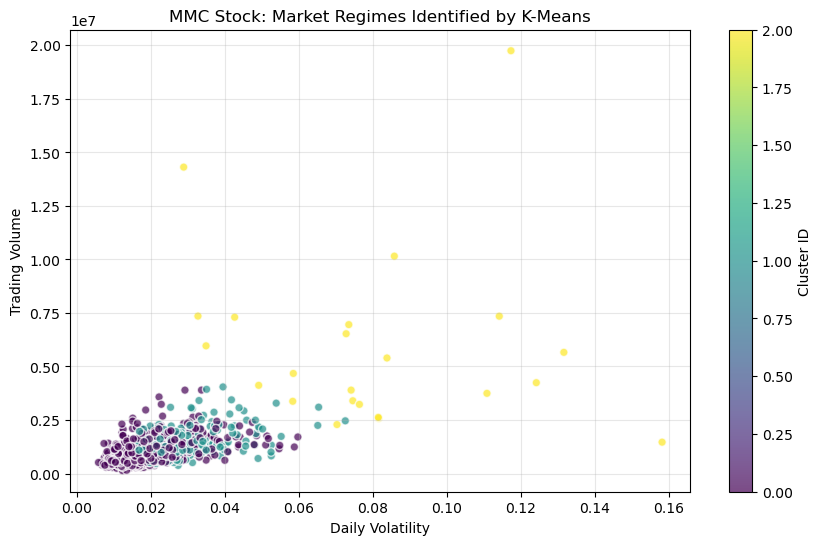

In [27]:
# Visualize the Regimes
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Volatility'],
    df['volume'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='w'
)

plt.xlabel('Daily Volatility')
plt.ylabel('Trading Volume')
plt.title('MMC Stock: Market Regimes Identified by K-Means')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()